<a href="https://colab.research.google.com/github/stefaniacatteddu/butterfly-classification/blob/main/butterfly_colab_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🦋 Butterfly Image Classification with CNN

In [2]:
#first we import the data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/archive(2).zip'
extract_to = '/content/butterfly_dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

data_dir = os.path.join(extract_to, 'train')


In [4]:
import pandas as pd
import numpy as np
import shutil
from tensorflow.keras.preprocessing.image import load_img, img_to_array

train_df = pd.read_csv('/content/butterfly_dataset/Training_set.csv')
test_df = pd.read_csv('/content/butterfly_dataset/Testing_set.csv')

#let's choose just 10 classes

top_classes = train_df['label'].value_counts().index[:10]
train_df = train_df[train_df['label'].isin(top_classes)].reset_index(drop=True)
train_df['label'] = train_df['label'].str.replace(' ', '_')

#Create Folders for Each Class
#Ensures only images that actually exist are used
for label in train_df['label'].unique():
    os.makedirs(os.path.join(extract_to, 'train', label), exist_ok=True)

#Filter & Move Images to Class Folders
available_files = set(os.listdir(os.path.join(extract_to, 'train')))
train_df = train_df[train_df['filename'].isin(available_files)].reset_index(drop=True)

# we move the images in the right folder
missing_files = 0
for _, row in train_df.iterrows():
    src = os.path.join(extract_to, 'train', row['filename'])
    dst = os.path.join(extract_to, 'train', row['label'], row['filename'])

    try:
        shutil.move(src, dst)
    except FileNotFoundError:
        print(f"missing file: {src}")
        missing_files += 1
# loading images (test) ( filename, no label)
#Loads each test image, resizes it to 128x128 pixels, converts it to an array, and normalizes it to values between 0 and 1.
test_df = pd.read_csv('/content/butterfly_dataset/Testing_set.csv')
IMG_SIZE = (128, 128)
X_test = []

for filename in test_df['filename']:
    path = os.path.join('/content/butterfly_dataset/test', filename)
    if os.path.exists(path):
        img = load_img(path, target_size=IMG_SIZE)
        X_test.append(img_to_array(img) / 255.0)





In [5]:
#creating training and validation datasets from your images, with real-time
#data augmentation to improve model generalization and performance.
#the following tool automatically loads, resizes and rescales
#It also helps split data into training and validation subsets.


from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (128, 128) #resizing
batch_size = 32 #32 images will be loaded per batch during training.

#data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,  #Normalizes pixel values from [0, 255] → [0, 1].
    validation_split=0.2, #Splits 20% of the dataset for validation.
    rotation_range=20, #Randomly rotates images by ±20 degrees.
    zoom_range=0.2, #random zoom in/out by 20%.
    shear_range=0.2, #Applies random shearing
    horizontal_flip=True #Randomly flips images horizontally.
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
#Load Training Data from Folders
train_generator = train_datagen.flow_from_directory(
    os.path.join(extract_to, 'train'),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)
#Load Validation Data from Folders
val_generator = val_datagen.flow_from_directory(
    os.path.join(extract_to, 'train'),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)


Found 816 images belonging to 10 classes.
Found 200 images belonging to 10 classes.


#CNN MODEL

In [6]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)), #Detects features (edges, textures, etc.) from input images
    MaxPooling2D(2,2), #Downsamples the feature maps to reduce computation and extract dominant features.
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'), #Fully connected layer that learns high-level representations.
    Dropout(0.5), #Randomly drops 50% of neurons during training to prevent overfitting.
    Dense(train_generator.num_classes, activation='softmax') #outputs probabilities for each of the 10 classes.
])

model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']) #Compiling the Model

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True) #early stopping to prevent overfitting

history_cnn = model_cnn.fit(train_generator, validation_data=val_generator, epochs=20, callbacks=[early_stop])
#Predictions on Test Data
X_test = np.array(X_test)
preds = model_cnn.predict(X_test)
pred_labels = np.argmax(preds, axis=1)
class_names = list(train_generator.class_indices.keys())
predicted = [class_names[i] for i in pred_labels]

test_df['predicted_label'] = predicted
test_df.to_csv('predizioni_test.csv', index=False)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 28s 988ms/step - accuracy: 0.1630 - loss: 2.5416 - val_accuracy: 0.4700 - val_loss: 1.7301
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 23s 882ms/step - accuracy: 0.4081 - loss: 1.6513 - val_accuracy: 0.5550 - val_loss: 1.3868
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.6152 - loss: 1.1382 - val_accuracy: 0.6750 - val_loss: 1.0425
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 25s 953ms/step - accuracy: 0.6642 - loss: 0.9479 - val_accuracy: 0.7400 - val_loss: 0.7906
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 23s 873ms/step - accuracy: 0.7157 - loss: 0.8574 - val_accuracy: 0.7800 - val_loss: 0.6564
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 25s 957ms/step - accuracy: 0.7561 - loss: 0.7409 - val_accuracy: 0.8400 - val_loss: 0.4835
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 23s 865ms/step - accuracy: 0.7782 - loss: 0.6853 - val_accuracy: 0.8400 - val_loss: 0.5139
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 25s 964ms/step - accuracy: 0.7904 - loss: 0.6202 - val_accurac

# Plot Accuracy and Loss

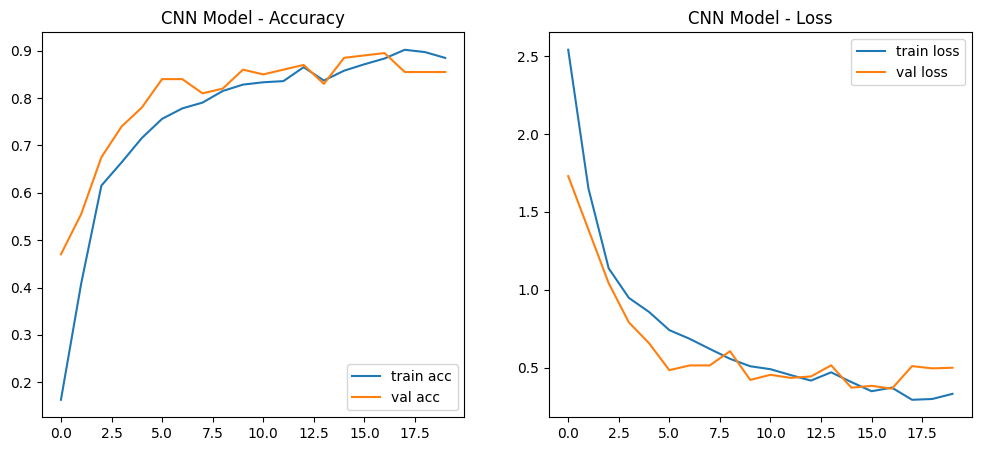

In [7]:
import matplotlib.pyplot as plt


def plot_history(history, title):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='train acc')
    plt.plot(history.history['val_accuracy'], label='val acc')
    plt.title(title + ' - Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='train loss')
    plt.plot(history.history['val_loss'], label='val loss')
    plt.title(title + ' - Loss')
    plt.legend()
    plt.show()



plot_history(history_cnn, 'CNN Model')


# Confusion Matrix

Found 816 images belonging to 10 classes.
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 287ms/step


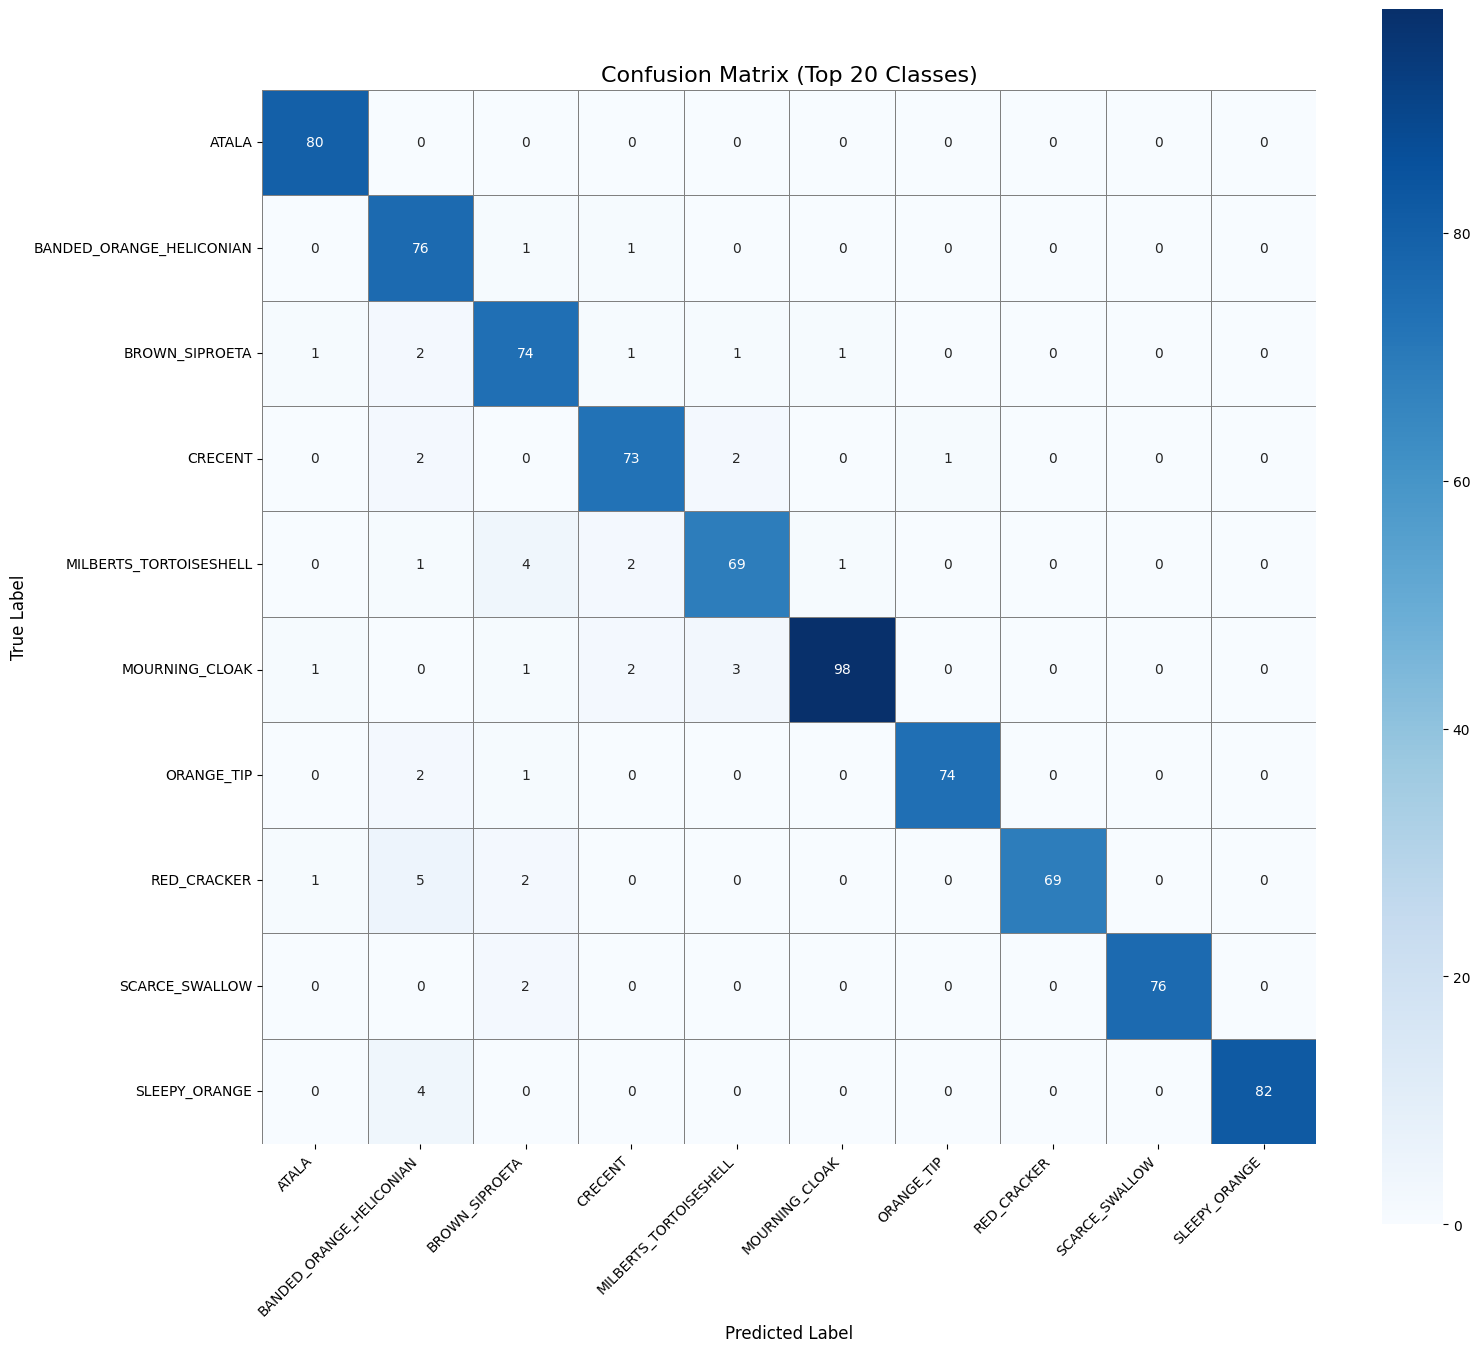

In [8]:
# top 20 most frequent classes
top_classes = train_df['label'].value_counts().index[:20]
train_df = train_df[train_df['label'].isin(top_classes)].reset_index(drop=True)


import os
import shutil

for label in top_classes:
    os.makedirs(os.path.join(extract_to, 'train', label), exist_ok=True)


for _, row in train_df.iterrows():
    src = os.path.join(extract_to, 'train', row['filename'])
    dst = os.path.join(extract_to, 'train', row['label'], row['filename'])
    if os.path.exists(src):
        shutil.move(src, dst)

# we remake the generator only with the 20 classes
train_generator = train_datagen.flow_from_directory(
    os.path.join(extract_to, 'train'),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=False  # Important for consistent label ordering
)


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


Y_pred = model_cnn.predict(train_generator)
y_pred = np.argmax(Y_pred, axis=1)
true_classes = train_generator.classes
class_labels = list(train_generator.class_indices.keys())

# confusion matrix
cm = confusion_matrix(true_classes, y_pred)

# Plot
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels,
            linewidths=0.5, linecolor='gray', square=True)

plt.title("Confusion Matrix (Top 20 Classes)", fontsize=16)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()



#Display of training images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step


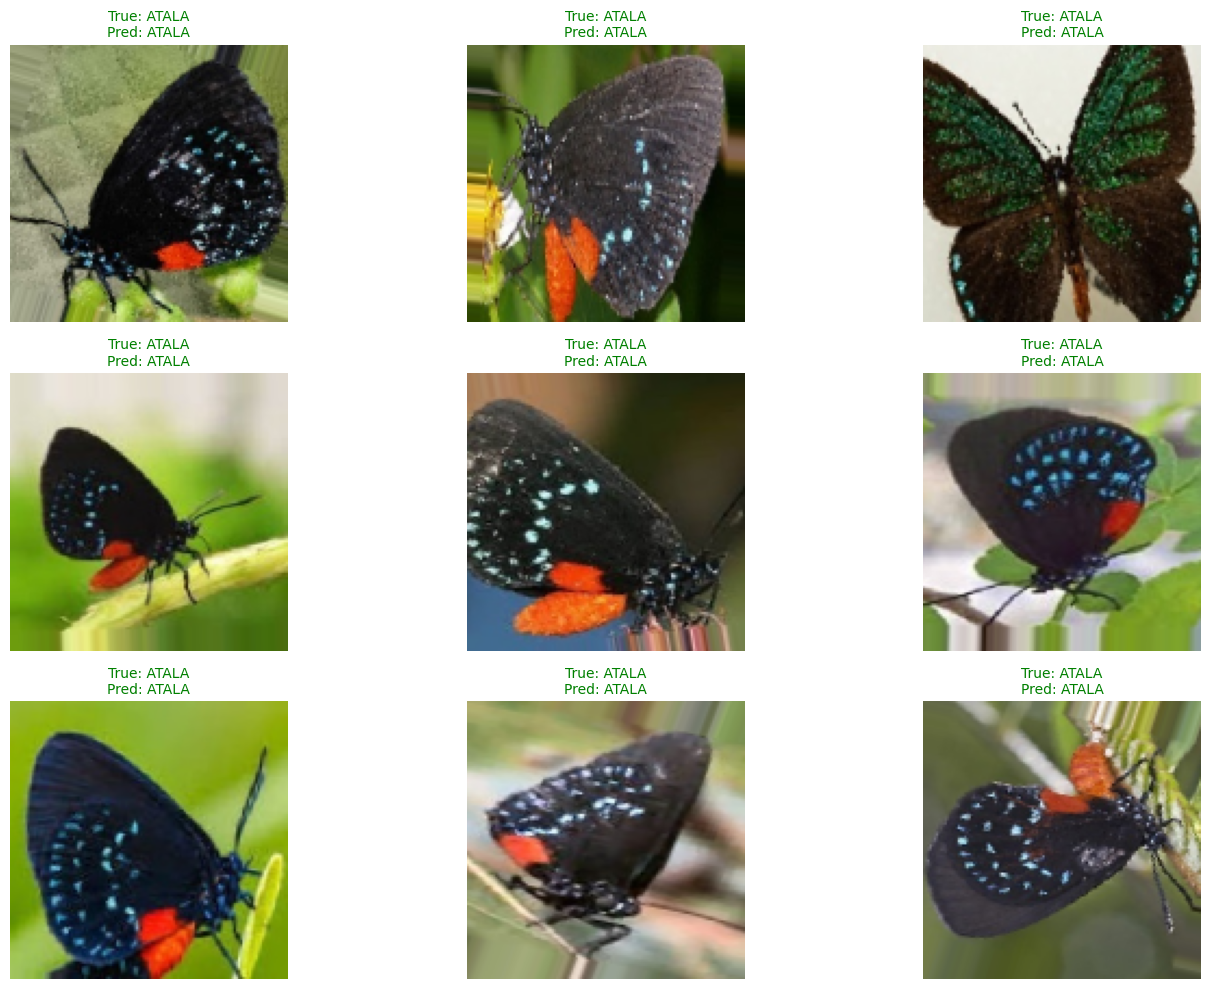

In [9]:
train_generator.reset()
x_test, y_test = next(train_generator)

predictions = model_cnn.predict(x_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

num_images = 9
unique_indices = np.random.choice(len(x_test), size=num_images, replace=False)

plt.figure(figsize=(15, 10))
for i, idx in enumerate(unique_indices):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[idx])
    plt.axis('off')
    true_label = class_labels[true_classes[idx]]
    pred_label = class_labels[predicted_classes[idx]]
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f'True: {true_label}\nPred: {pred_label}', color=color, fontsize=10)
plt.tight_layout()
plt.show()


# CNN MODEL 2


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Second architecture (deeper)
model_cnn_v2 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),   # more layer
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),           # more neurons
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])


model_cnn_v2.compile(optimizer='adam',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

# Early stopping
early_stop_v2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Training
history_cnn_v2 = model_cnn_v2.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop_v2]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.0355 - loss: 2.6132 - val_accuracy: 0.0600 - val_loss: 2.3022
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.0515 - loss: 2.3054 - val_accuracy: 0.1300 - val_loss: 2.3021
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.0809 - loss: 2.3064 - val_accuracy: 0.1500 - val_loss: 2.2957
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.1471 - loss: 2.2956 - val_accuracy: 0.1700 - val_loss: 2.2646
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.1728 - loss: 2.2644 - val_accuracy: 0.2900 - val_loss: 2.1470
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.2267 - loss: 2.1714 - val_accuracy: 0.3900 - val_loss: 1.9185
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.2059 - loss: 2.2110 - val_accuracy: 0.3100 - val_loss: 2.0863
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.3125 - loss: 2.0637 - val_accuracy: 0.4850 - val_loss:

# Plot Accuracy and Loss

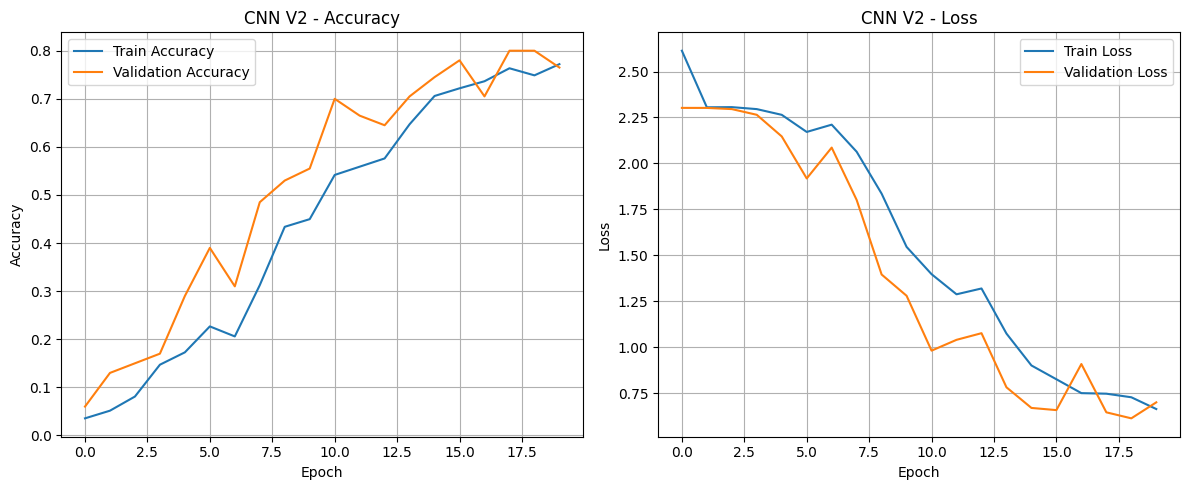

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_cnn_v2.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn_v2.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN V2 - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_cnn_v2.history['loss'], label='Train Loss')
plt.plot(history_cnn_v2.history['val_loss'], label='Validation Loss')
plt.title('CNN V2 - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



# Confusion Matrix CNN2

Found 816 images belonging to 10 classes.
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 435ms/step


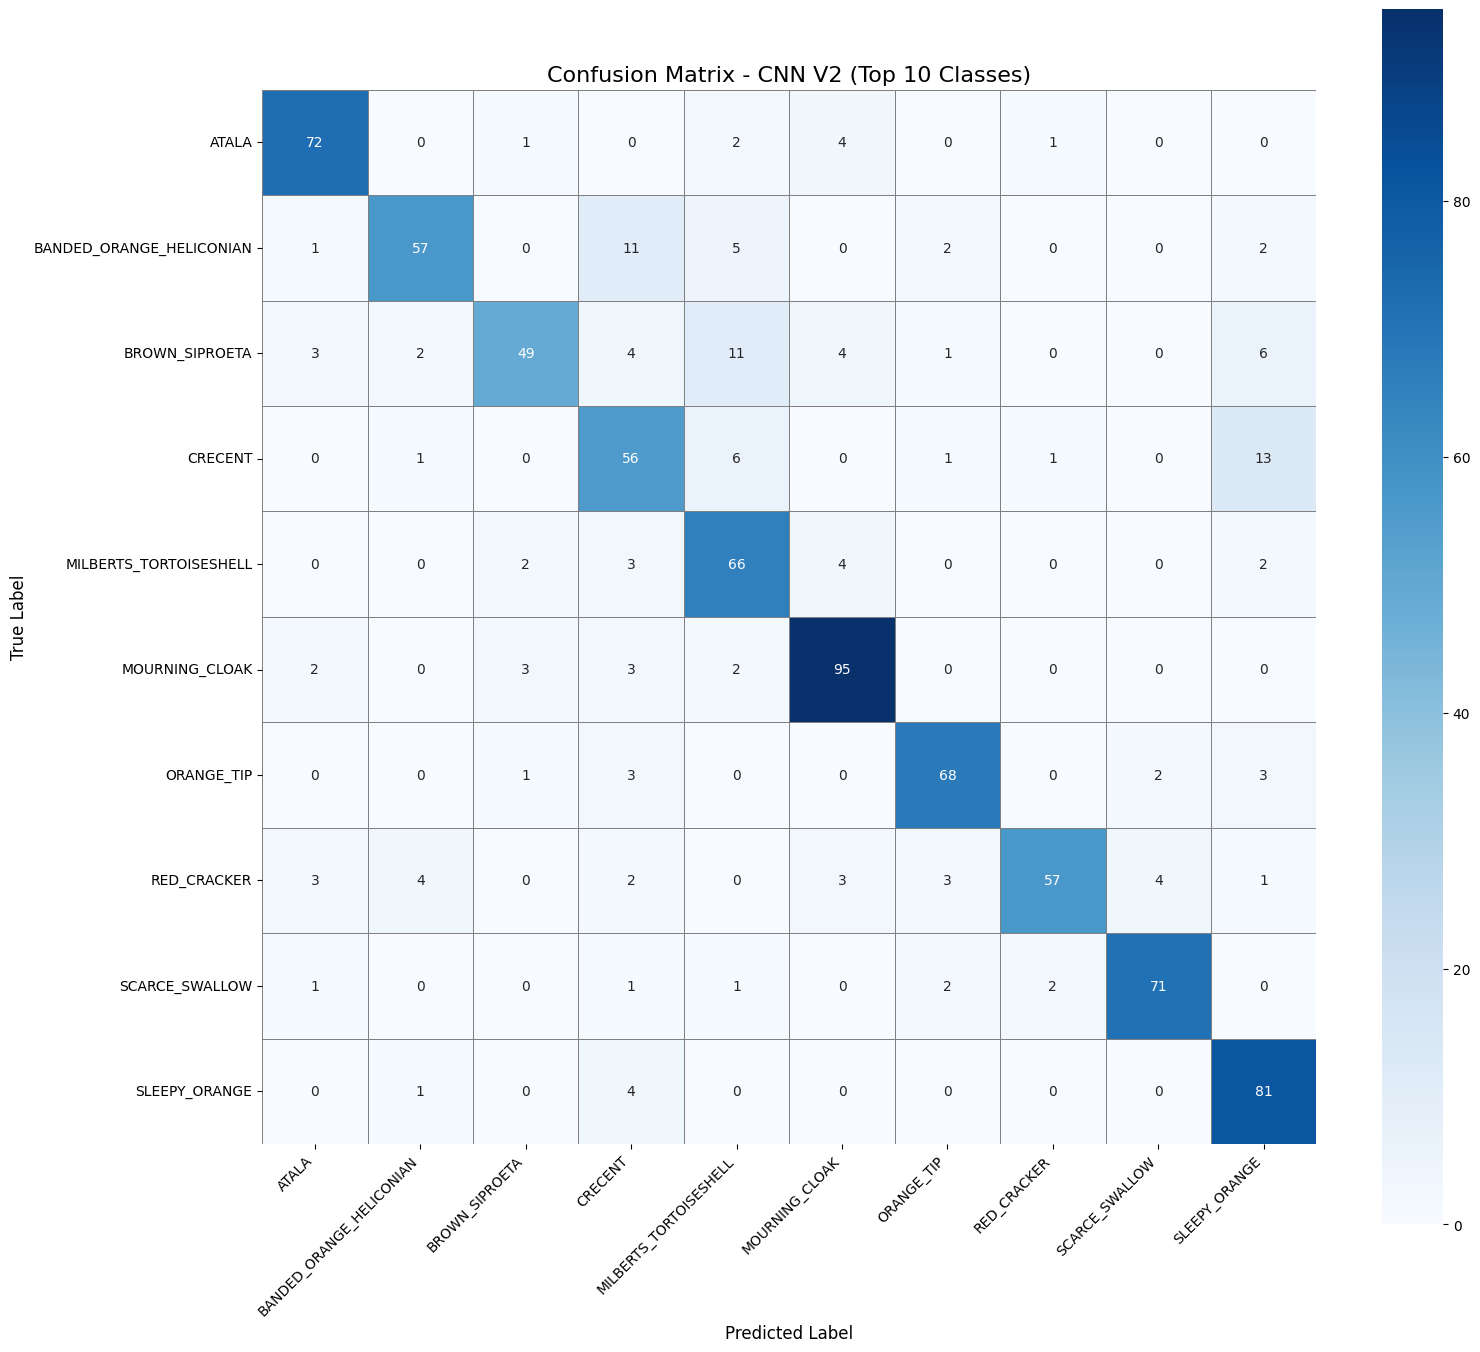

In [12]:
#  top 10 most frequent classes
top_classes = train_df['label'].value_counts().index[:10]
train_df = train_df[train_df['label'].isin(top_classes)].reset_index(drop=True)

# Normalizzation folders
train_df['label'] = train_df['label'].str.replace(' ', '_')


import os
import shutil

for label in top_classes:
    os.makedirs(os.path.join(extract_to, 'train', label), exist_ok=True)


for _, row in train_df.iterrows():
    src = os.path.join(extract_to, 'train', row['filename'])
    dst = os.path.join(extract_to, 'train', row['label'], row['filename'])
    if os.path.exists(src):
        shutil.move(src, dst)


train_generator = train_datagen.flow_from_directory(
    os.path.join(extract_to, 'train'),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=False
)

#Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Y_pred = model_cnn_v2.predict(train_generator)
y_pred = np.argmax(Y_pred, axis=1)
true_classes = train_generator.classes
class_labels = list(train_generator.class_indices.keys())

cm = confusion_matrix(true_classes, y_pred)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels,
            linewidths=0.5, linecolor='gray', square=True)

plt.title("Confusion Matrix - CNN V2 (Top 10 Classes)", fontsize=16)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()